# Quantifying Retrieval Fidelity in RAG Systems


## 1. Dataset and Problem Setup

First, we need to load the data. We are using the **SQuAD 2.0 dataset** because it includes "impossible" queries : trick questions designed by humans to look highly relevant to a paragraph, even though the answer isn't actually there.

To make sure our models are evaluated fairly, we build a perfectly balanced dataset of 4,000 pairs: true matches, completely random noise, and the tricky adversarial noise.

In [10]:
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split, cross_validate, validation_curve
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import ListedColormap

# Load SQuAD 2.0 dataset
with open('dev-v2.0.json', 'r') as f:
    squad_data = json.load(f)

# Extract true matches and impossible trick questions
positives, impossible_noise = [], []
for article in squad_data['data']:
    for paragraph in article['paragraphs']:
        context = paragraph['context']
        for qa in paragraph['qas']:
            if qa['is_impossible']:
                impossible_noise.append({'query': qa['question'], 'context': context, 'label': 0, 'noise_type': 'impossible'})
            else:
                positives.append({'query': qa['question'], 'context': context, 'label': 1, 'noise_type': 'none'})

# Generate random mismatch noise for baseline comparison
all_contexts = [p['context'] for a in squad_data['data'] for p in a['paragraphs']]
random_noise = []
for p in positives[:2000]:
    random_context = random.choice(all_contexts)
    if random_context != p['context']:
        random_noise.append({'query': p['query'], 'context': random_context, 'label': 0, 'noise_type': 'random'})

# Build the final balanced dataset and shuffle it
df = pd.DataFrame(positives[:2000] + impossible_noise[:1000] + random_noise[:1000])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

## 2. Creating the Features

Machine learning models can't read raw text, so we need to convert our queries and contexts into numbers using a `SentenceTransformer`.

Instead of feeding hundreds of dimensions to our models, we extract two specific metrics to keep things interpretable:
1. **Cosine Similarity:** To measure the overall semantic meaning and topic overlap.
2. **Jaccard Overlap:** To check for the exact percentage of shared words, helping us catch subtle tricks like swapped names or dates.

In [11]:
# Convert text into dense vector embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
q_embeddings = model.encode(df['query'].tolist())
c_embeddings = model.encode(df['context'].tolist())

cos_sim, jaccard_overlap = [], []

# Calculate semantic and lexical overlap
for i in range(len(df)):
    q_vec = q_embeddings[i].reshape(1, -1)
    c_vec = c_embeddings[i].reshape(1, -1)

    # Angular semantic similarity
    cos_sim.append(cosine_similarity(q_vec, c_vec)[0][0])

    # Exact word intersection
    q_words = set(df['query'].iloc[i].lower().split())
    c_words = set(df['context'].iloc[i].lower().split())

    intersect = len(q_words.intersection(c_words))
    union = len(q_words.union(c_words))
    jaccard_overlap.append(intersect / union if union > 0 else 0)

# Create the final 2D feature matrix
X = pd.DataFrame({'cosine': cos_sim, 'jaccard': jaccard_overlap})
y = df['label']
noise_types = df['noise_type']

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 3. Data Exploration and Dropping Features

Let's look at what our data actually looks like. We will plot the distribution of our Cosine Similarity scores and check the correlation between our features.


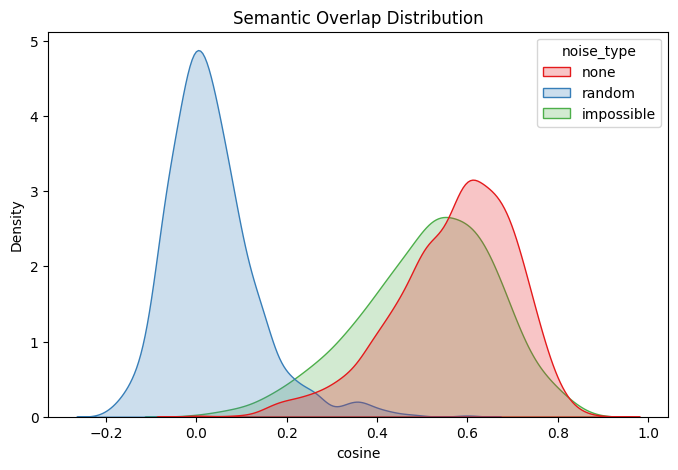

In [12]:
# Visualize how semantic overlap differs across the noise types
plot_df = X.copy()
plot_df['noise_type'] = noise_types

plt.figure(figsize=(8, 5))
sns.kdeplot(data=plot_df, x='cosine', hue='noise_type', fill=True, common_norm=False, palette='Set1')
plt.title("Semantic Overlap Distribution")
plt.savefig('feature_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Unsupervised Learning (Clustering)

Before giving the models the true labels, we want to test if the problem can be solved automatically.

**Our Hypothesis:** We are using a Gaussian Mixture Model (GMM) via the EM algorithm to see if the trick questions naturally form a different cluster than the real answers in the vector space. Let's see if the data groups itself correctly without human intervention.

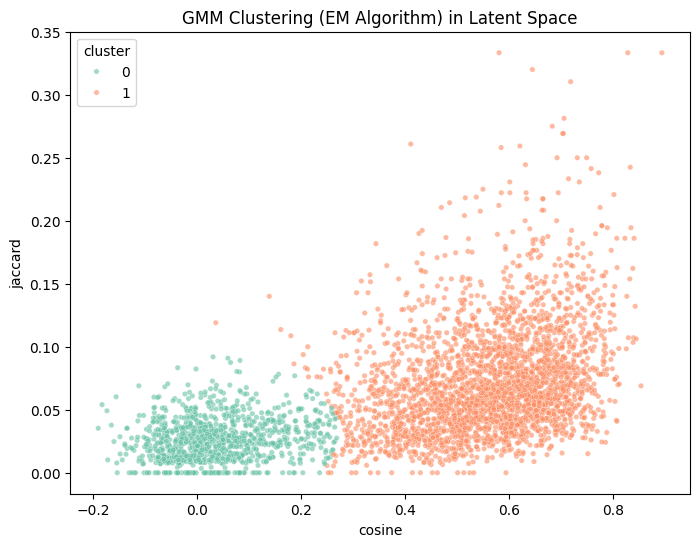

In [13]:
# Apply Gaussian Mixture Model to see if the data clusters naturally
gmm = GaussianMixture(n_components=2, random_state=42)
X_clust = X.copy()
X_clust['cluster'] = gmm.fit_predict(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=X_clust, x='cosine', y='jaccard', hue='cluster', palette='Set2', s=15, alpha=0.6)
plt.title("GMM Clustering (EM Algorithm) in Latent Space")
plt.savefig('unsupervised_em.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Supervised Learning: Method Selection

As we saw in the clustering plot, unsupervised learning failed, the trick questions perfectly overlap with the true matches. We absolutely need supervised learning to draw a boundary. We will train and compare four different models:

* **LDA:** A generative model looking for normal bell-curve distributions.
* **Naive Bayes:** A probabilistic model assuming features are independent.
* **Decision Tree:** A rule-based model that draws strict "if/then" flowchart boxes.
* **Logistic Regression:** A discriminative model looking for a smooth, flexible dividing line.

We will evaluate them using 5-fold cross-validation.

In [14]:
# Split data for supervised model training
X_train, X_test, y_train, y_test, noise_train, noise_test = train_test_split(
    X, y, noise_types, test_size=0.2, random_state=42)

# Define the 4 core models
models = {
    "Logistic Reg": LogisticRegression(penalty='l2', C=1.0),
    "LDA": LinearDiscriminantAnalysis(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', max_depth=4)
}

# Evaluate each model
results = []
for name, clf in models.items():
    clf.fit(X_train, y_train)
    cv = cross_validate(clf, X, y, cv=5, scoring=['accuracy', 'precision', 'recall', 'roc_auc'])
    results.append({
        "Model": name,
        "Accuracy": np.mean(cv['test_accuracy']),
        "Precision": np.mean(cv['test_precision']),
        "Recall": np.mean(cv['test_recall']),
        "AUC": np.mean(cv['test_roc_auc'])
    })

print(pd.DataFrame(results).set_index("Model").round(3))

               Accuracy  Precision  Recall    AUC
Model                                            
Logistic Reg      0.740      0.704   0.830  0.809
LDA               0.746      0.701   0.859  0.812
Naive Bayes       0.743      0.692   0.876  0.788
Decision Tree     0.739      0.685   0.886  0.798


## 6. Decision Boundaries and Catching Trick Questions

Now we visualize how each model mathematically drew the line between good and bad documents.

More importantly, we run our final adversarial test. Overall accuracy doesn't matter as much as the **True Negative Rate**, meaning, when the system encounters a bad document, how often does it actually reject the SQuAD trick questions compared to the easy random paragraphs?

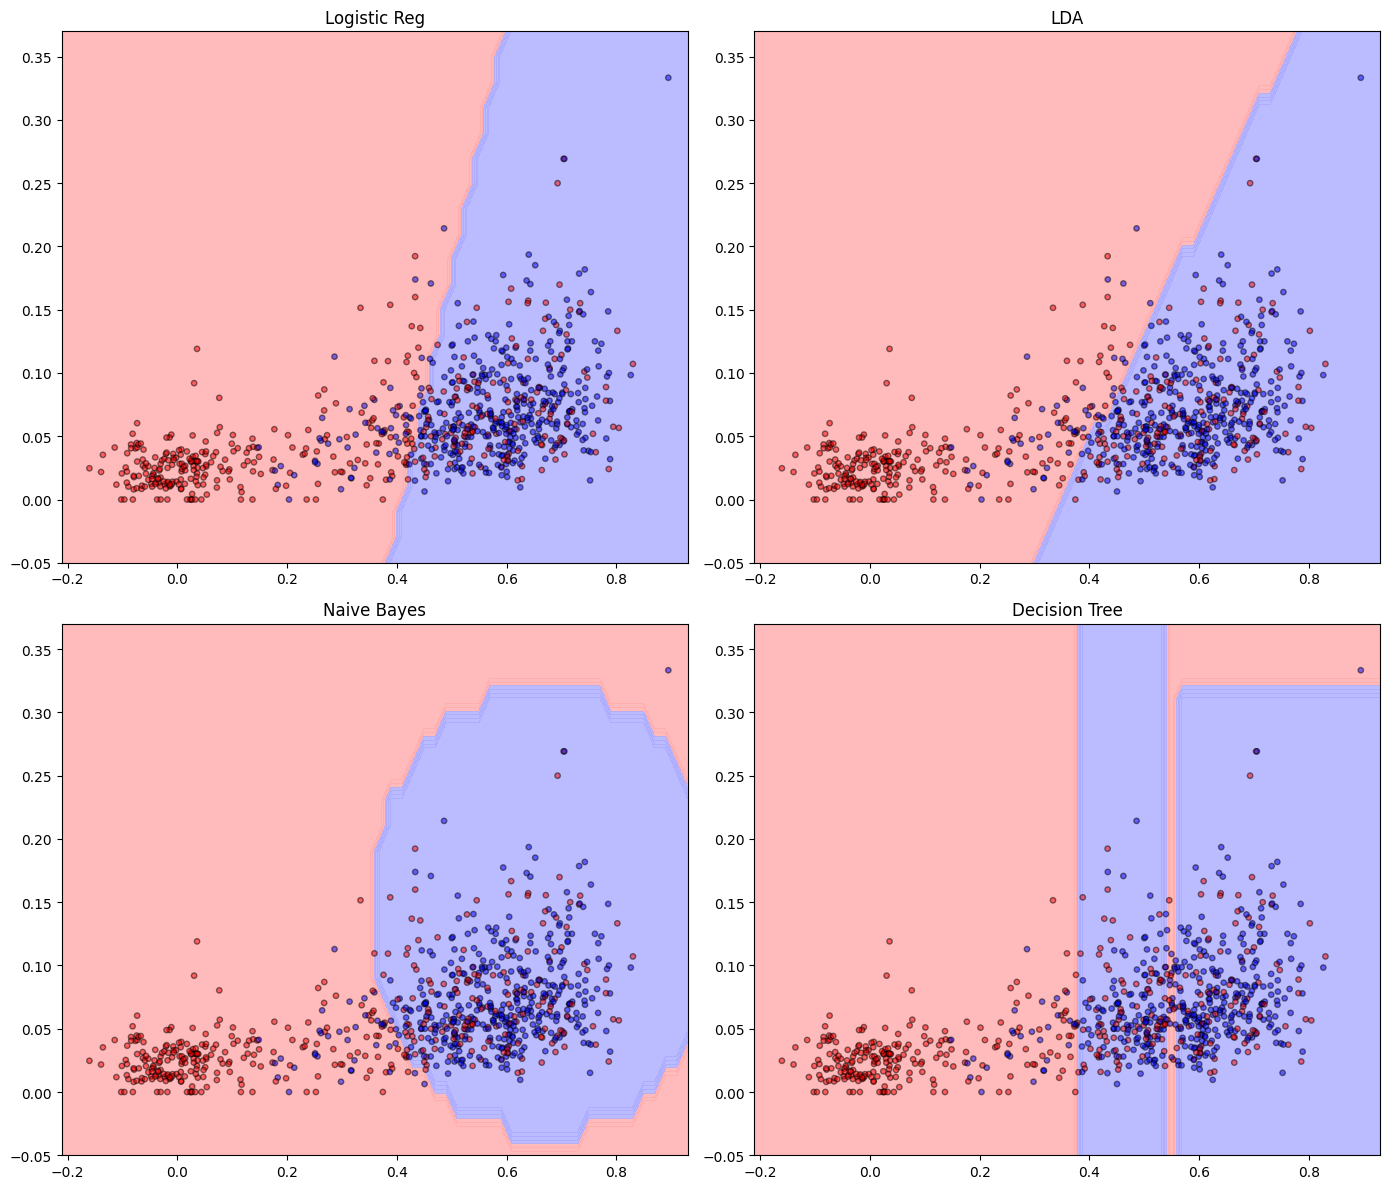

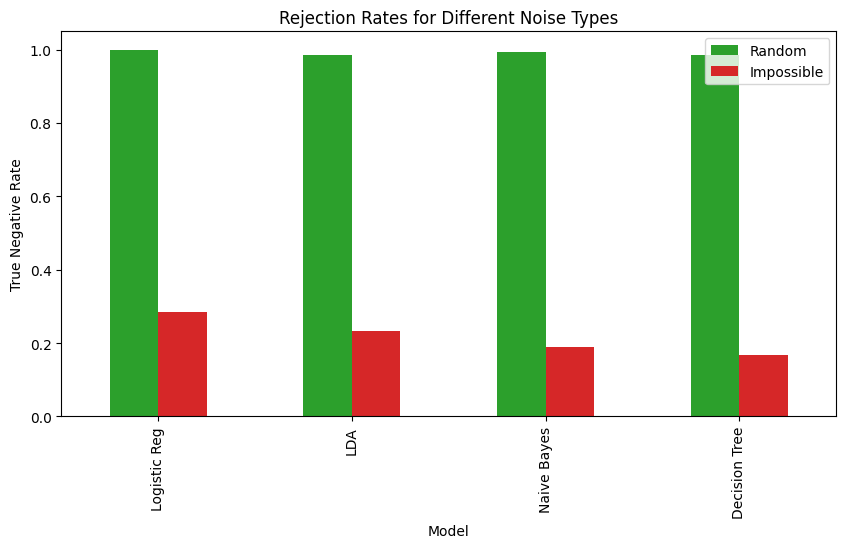

In [15]:
# Helper function to map the decision boundaries
def plot_boundaries(clf, X_data, y_data, title, ax):
    x_min, x_max = X_data['cosine'].min() - 0.05, X_data['cosine'].max() + 0.05
    y_min, y_max = X_data['jaccard'].min() - 0.05, X_data['jaccard'].max() + 0.05
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = clf.predict(pd.DataFrame({'cosine': xx.ravel(), 'jaccard': yy.ravel()})).reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']), alpha=0.8)
    ax.scatter(X_data['cosine'], X_data['jaccard'], c=y_data, cmap=ListedColormap(['#FF0000', '#0000FF']), edgecolor='k', s=15, alpha=0.5)
    ax.set_title(title)

# Plot boundaries for all 4 models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (name, clf) in zip(axes.ravel(), models.items()):
    plot_boundaries(clf, X_test, y_test, name, ax)
plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate and plot how well models reject the impossible trick queries
errs = []
for name, clf in models.items():
    preds = clf.predict(X_test)
    test_df = pd.DataFrame({'type': noise_test, 'pred': preds})

    rand_rej = 1 - test_df[test_df['type'] == 'random']['pred'].mean()
    imp_rej = 1 - test_df[test_df['type'] == 'impossible']['pred'].mean()
    errs.append({'Model': name, 'Random': rand_rej, 'Impossible': imp_rej})

pd.DataFrame(errs).set_index('Model').plot(kind='bar', figsize=(10, 5), color=['#2ca02c', '#d62728'])
plt.title("Rejection Rates for Different Noise Types")
plt.ylabel("True Negative Rate")
plt.savefig('adversarial_rejection.png', bbox_inches='tight')
plt.show()

## 7. Testing for Overfitting (Bias-Variance Tradeoff)

Finally, we run validation curves to make sure our models actually learned the underlying rules of the language rather than just memorizing the training data.

We will check how deep the Decision Tree can grow before it starts to overfit, and we will find the optimal L2 regularization parameter (`C`) to keep our Logistic Regression model balanced and reliable.

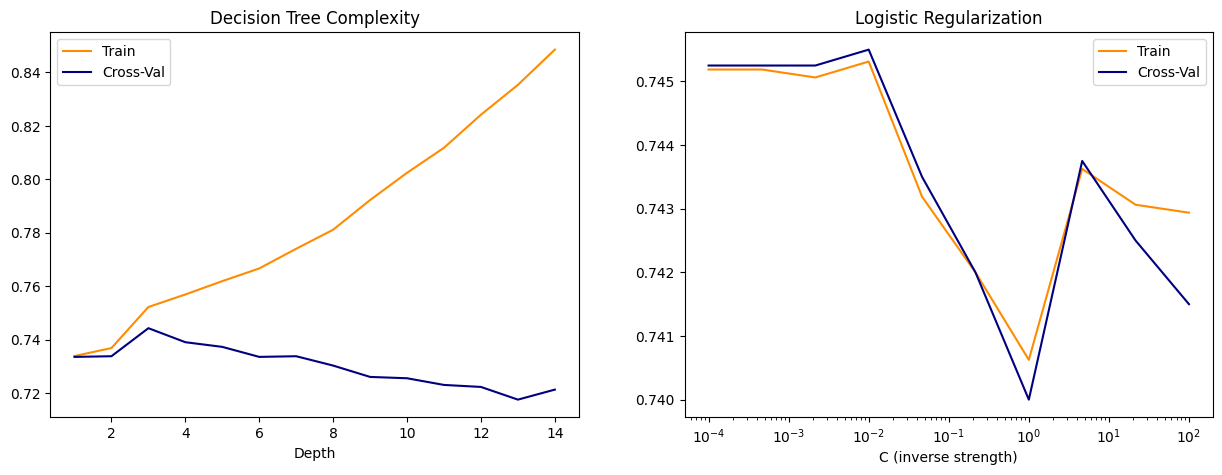

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Validation curve for Decision Tree depth
depths = np.arange(1, 15)
tr_tree, te_tree = validation_curve(DecisionTreeClassifier(criterion='entropy'), X, y, param_name="max_depth", param_range=depths, cv=5)
axes[0].plot(depths, np.mean(tr_tree, axis=1), label="Train", color="darkorange")
axes[0].plot(depths, np.mean(te_tree, axis=1), label="Cross-Val", color="navy")
axes[0].set_title("Decision Tree Complexity")
axes[0].set_xlabel("Depth")
axes[0].legend()

# Validation curve for Logistic Regression regularization
c_vals = np.logspace(-4, 2, 10)
tr_log, te_log = validation_curve(LogisticRegression(max_iter=1000), X, y, param_name="C", param_range=c_vals, cv=5)
axes[1].semilogx(c_vals, np.mean(tr_log, axis=1), label="Train", color="darkorange")
axes[1].semilogx(c_vals, np.mean(te_log, axis=1), label="Cross-Val", color="navy")
axes[1].set_title("Logistic Regularization")
axes[1].set_xlabel("C (inverse strength)")
axes[1].legend()

plt.savefig('validation_curves.png', dpi=300, bbox_inches='tight')
plt.show()